# Voice analysis

### PART 1. IMPORTS AND CONFIG

In [19]:
import os
import json
import tempfile
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import soundfile as sf
import parselmouth
from parselmouth.praat import call
from matplotlib.patches import Patch

AUDIO_FILE = "sample.m4a"
TARGET_SR = 16000
FRAME_LENGTH = 2048
HOP_LENGTH = 512
FMIN = 50
FMAX = 400

# Silence threshold: frames with RMS below this level are treated as pauses
SILENCE_THRESHOLD_DB = -40   # dB; lower (e.g. -35) if background noise is high

### PART 2. LOAD AUDIO

In [20]:
if not os.path.exists(AUDIO_FILE):
    raise FileNotFoundError(f"File not found: {AUDIO_FILE}")

y, sr = librosa.load(AUDIO_FILE, sr=TARGET_SR, mono=True)
duration_sec = librosa.get_duration(y=y, sr=sr)
print(f"Loaded: {AUDIO_FILE} | SR={sr} | Duration={duration_sec:.2f}s")

# Praat (parselmouth) does not support .m4a / .mp3 directly.
# We write a temporary WAV from the already-decoded librosa array —
# no extra ffmpeg call needed.
_wav_tmp = tempfile.NamedTemporaryFile(suffix=".wav", delete=False)
WAV_FILE = _wav_tmp.name
_wav_tmp.close()

sf.write(WAV_FILE, y, sr, subtype="PCM_16")
print(f"Temporary WAV written for Praat: {WAV_FILE}")

# Parselmouth Sound object — reads from the WAV file
snd = parselmouth.Sound(WAV_FILE)


Loaded: sample.m4a | SR=16000 | Duration=19.50s
Temporary WAV written for Praat: /var/folders/1k/vrdhlm2d26jdy9x305v501zw0000gn/T/tmp4ct3uzqq.wav


/var/folders/1k/vrdhlm2d26jdy9x305v501zw0000gn/T/ipykernel_11010/1473319598.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(AUDIO_FILE, sr=TARGET_SR, mono=True)
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


### PART 3. SEGMENTATION (equal-length chunks)

In [21]:
N_PARTS = 5
samples_per_part = len(y) // N_PARTS
segments = []

for i in range(N_PARTS):
    start = i * samples_per_part
    end = (i + 1) * samples_per_part if i < N_PARTS - 1 else len(y)
    segments.append({
        "part": i + 1,
        "start_time": start / sr,
        "end_time": end / sr,
        "audio": y[start:end]
    })

### PART 4. ANALYSIS FUNCTIONS

In [22]:
# --- 4A. TIMBRE ---
# Extends baseline MFCCs with:
#   delta-MFCCs      — rate of change of timbre frame-to-frame
#   Spectral contrast — depth of spectral peaks vs valleys across bands
#   Chroma            — tonal energy distribution across pitch classes

def analyze_timbre(audio, sr, hop_length=512):
    """
    Timbre is the spectral 'colour' of a voice beyond pitch and loudness.
    Delta-MFCCs capture how quickly timbre changes over time.
    Spectral contrast measures the relief of the spectrum (peaks vs valleys).
    Chroma variance reflects how tonally focused the voice is.
    """
    mfcc        = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13, hop_length=hop_length)
    delta_mfcc  = librosa.feature.delta(mfcc)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)

    # Spectral contrast across 7 frequency bands
    contrast = librosa.feature.spectral_contrast(y=audio, sr=sr, hop_length=hop_length)

    # Chroma STFT — 12 pitch classes
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr, hop_length=hop_length)

    result = {}

    # MFCC summary statistics (mean + std per coefficient)
    for i in range(mfcc.shape[0]):
        result[f"mfcc_{i+1}_mean"] = float(np.mean(mfcc[i]))
        result[f"mfcc_{i+1}_std"]  = float(np.std(mfcc[i]))

    # Delta-MFCC: mean absolute movement of timbre
    result["delta_mfcc_mean_abs"]  = float(np.mean(np.abs(delta_mfcc)))
    result["delta2_mfcc_mean_abs"] = float(np.mean(np.abs(delta2_mfcc)))

    # Spectral contrast: mean per band
    for b in range(contrast.shape[0]):
        result[f"spec_contrast_band{b+1}"] = float(np.mean(contrast[b]))

    # Chroma variance: how focused the voice is on particular pitches
    result["chroma_variance"] = float(np.var(np.mean(chroma, axis=1)))

    return result


# --- 4B. VOICE QUALITY ---
# Formants F1/F2/F3 via Praat — vocal tract resonances, characterise vowels
# HNR (Harmonics-to-Noise Ratio) — voice clarity / breathiness
# Jitter  — cycle-to-cycle F0 instability (roughness, tremor)
# Shimmer — cycle-to-cycle amplitude instability

def analyze_voice_quality(snd_full, start_time, end_time):
    """
    Uses Praat through parselmouth.
    Extracts a segment of the Sound object and computes voice biomarkers.
    """
    part_snd = snd_full.extract_part(
        from_time=start_time,
        to_time=end_time,
        preserve_times=False
    )

    result = {}

    # --- Formants ---
    try:
        formant  = call(part_snd, "To Formant (burg)", 0, 5, 5500, 0.025, 50)
        duration = end_time - start_time
        n_points = max(1, int(duration / 0.01))  # sample every 10 ms

        f1_vals, f2_vals, f3_vals = [], [], []
        for t_idx in range(n_points):
            t  = t_idx * 0.01
            f1 = call(formant, "Get value at time", 1, t, "Hertz", "Linear")
            f2 = call(formant, "Get value at time", 2, t, "Hertz", "Linear")
            f3 = call(formant, "Get value at time", 3, t, "Hertz", "Linear")
            if not np.isnan(f1): f1_vals.append(f1)
            if not np.isnan(f2): f2_vals.append(f2)
            if not np.isnan(f3): f3_vals.append(f3)

        result["F1_mean_hz"] = float(np.mean(f1_vals)) if f1_vals else np.nan
        result["F2_mean_hz"] = float(np.mean(f2_vals)) if f2_vals else np.nan
        result["F3_mean_hz"] = float(np.mean(f3_vals)) if f3_vals else np.nan
        result["F1_std_hz"]  = float(np.std(f1_vals))  if f1_vals else np.nan
        result["F2_std_hz"]  = float(np.std(f2_vals))  if f2_vals else np.nan

    except Exception as e:
        print(f"  [Formant error] {e}")
        result.update({"F1_mean_hz": np.nan, "F2_mean_hz": np.nan,
                        "F3_mean_hz": np.nan, "F1_std_hz": np.nan, "F2_std_hz": np.nan})

    # --- HNR (Harmonics-to-Noise Ratio) ---
    try:
        harmonicity = call(part_snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr = call(harmonicity, "Get mean", 0, 0)
        result["HNR_dB"] = float(hnr) if not np.isnan(hnr) else np.nan
    except Exception as e:
        print(f"  [HNR error] {e}")
        result["HNR_dB"] = np.nan

    # --- Jitter and Shimmer ---
    try:
        pitch         = call(part_snd, "To Pitch", 0, FMIN, FMAX)
        point_process = call([part_snd, pitch], "To PointProcess (cc)")

        # Local jitter: % cycle-to-cycle F0 variation
        jitter_local = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        result["jitter_local_pct"] = float(jitter_local * 100) if jitter_local else np.nan

        # Local shimmer in dB: amplitude cycle-to-cycle variation
        shimmer_dB = call([part_snd, point_process],
                          "Get shimmer (local_dB)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        result["shimmer_local_dB"] = float(shimmer_dB) if shimmer_dB else np.nan

    except Exception as e:
        print(f"  [Jitter/Shimmer error] {e}")
        result["jitter_local_pct"] = np.nan
        result["shimmer_local_dB"] = np.nan

    return result


# --- 4C. PAUSES AND SPEECH RHYTHM ---
# Detects silence based on frame-level RMS energy.
# Returns per-segment statistics and a list of individual pause events.

def analyze_pauses(audio, sr, threshold_db=SILENCE_THRESHOLD_DB,
                   hop_length=512, min_pause_frames=3):
    """
    Detects pauses as contiguous regions where RMS energy < threshold_db.
    min_pause_frames: minimum consecutive silent frames to count as a pause
                      (filters out micro-silences between phonemes).
    """
    rms    = librosa.feature.rms(y=audio, hop_length=hop_length)[0]
    rms_db = librosa.amplitude_to_db(rms, ref=np.max)

    is_silent      = rms_db < threshold_db
    frame_duration = hop_length / sr

    pauses    = []
    in_pause  = False
    pause_start = 0

    for i, silent in enumerate(is_silent):
        if silent and not in_pause:
            in_pause    = True
            pause_start = i
        elif not silent and in_pause:
            pause_len = i - pause_start
            if pause_len >= min_pause_frames:
                pauses.append({
                    "start_sec":    pause_start * frame_duration,
                    "end_sec":      i * frame_duration,
                    "duration_sec": pause_len * frame_duration
                })
            in_pause = False

    # Handle a pause that reaches the very end of the segment
    if in_pause:
        pause_len = len(is_silent) - pause_start
        if pause_len >= min_pause_frames:
            pauses.append({
                "start_sec":    pause_start * frame_duration,
                "end_sec":      len(is_silent) * frame_duration,
                "duration_sec": pause_len * frame_duration
            })

    total_dur   = len(audio) / sr
    total_pause = sum(p["duration_sec"] for p in pauses)
    speech_dur  = total_dur - total_pause

    stats = {
        "n_pauses":          len(pauses),
        "total_pause_sec":   float(total_pause),
        "speech_ratio":      float(speech_dur / total_dur) if total_dur > 0 else np.nan,
        "mean_pause_sec":    float(np.mean([p["duration_sec"] for p in pauses])) if pauses else 0.0,
        "max_pause_sec":     float(max([p["duration_sec"]  for p in pauses]))    if pauses else 0.0,
        "pauses_per_second": float(len(pauses) / speech_dur) if speech_dur > 0 else np.nan,
    }

    return stats, pauses


### PART 5. RUN ANALYSIS ACROSS ALL SEGMENTS

In [23]:
all_results       = []
all_pauses_detail = []

for s in segments:
    print(f"\n--- Part {s['part']} ({s['start_time']:.2f}s – {s['end_time']:.2f}s) ---")

    timbre             = analyze_timbre(s["audio"], sr, HOP_LENGTH)
    quality            = analyze_voice_quality(snd, s["start_time"], s["end_time"])
    pause_stats, pause_list = analyze_pauses(s["audio"], sr)

    row = {
        "part":           s["part"],
        "start_time_sec": s["start_time"],
        "end_time_sec":   s["end_time"],
        **timbre,
        **quality,
        **pause_stats
    }
    all_results.append(row)

    for p in pause_list:
        all_pauses_detail.append({
            "part":      s["part"],
            "abs_start": s["start_time"] + p["start_sec"],
            **p
        })

results_df = pd.DataFrame(all_results)
pauses_df  = pd.DataFrame(all_pauses_detail)

print("\n\n=== KEY RESULTS ===")
key_cols = ["part", "F1_mean_hz", "F2_mean_hz", "F3_mean_hz",
            "HNR_dB", "jitter_local_pct", "shimmer_local_dB",
            "n_pauses", "speech_ratio", "mean_pause_sec"]
print(results_df[key_cols].to_string(index=False))


--- Part 1 (0.00s – 3.90s) ---

--- Part 2 (3.90s – 7.80s) ---

--- Part 3 (7.80s – 11.70s) ---

--- Part 4 (11.70s – 15.60s) ---

--- Part 5 (15.60s – 19.50s) ---


=== KEY RESULTS ===
 part  F1_mean_hz  F2_mean_hz  F3_mean_hz    HNR_dB  jitter_local_pct  shimmer_local_dB  n_pauses  speech_ratio  mean_pause_sec
    1  600.792633 1697.049020 3096.173337  9.737764          2.635148          1.333672         0           1.0             0.0
    2  656.842780 1798.256610 3034.790833 11.815836          2.616523          1.208249         0           1.0             0.0
    3  557.525571 1615.150605 2806.971247 12.168578          2.114380          1.040831         0           1.0             0.0
    4  533.086016 1798.034537 2808.372548 13.794502          2.738557          1.244563         0           1.0             0.0
    5  654.263640 1619.860783 2841.181320  9.153202          3.442917          1.633021         0           1.0             0.0


### PART 6. SAVE RESULTS

In [24]:
results_df.to_csv("voice_analysis_extended.csv", index=False)
pauses_df.to_csv("voice_pauses_detail.csv", index=False)
print("\nSaved: voice_analysis_extended.csv, voice_pauses_detail.csv")


Saved: voice_analysis_extended.csv, voice_pauses_detail.csv


### PART 7. VISUALISATIONS — main dashboard

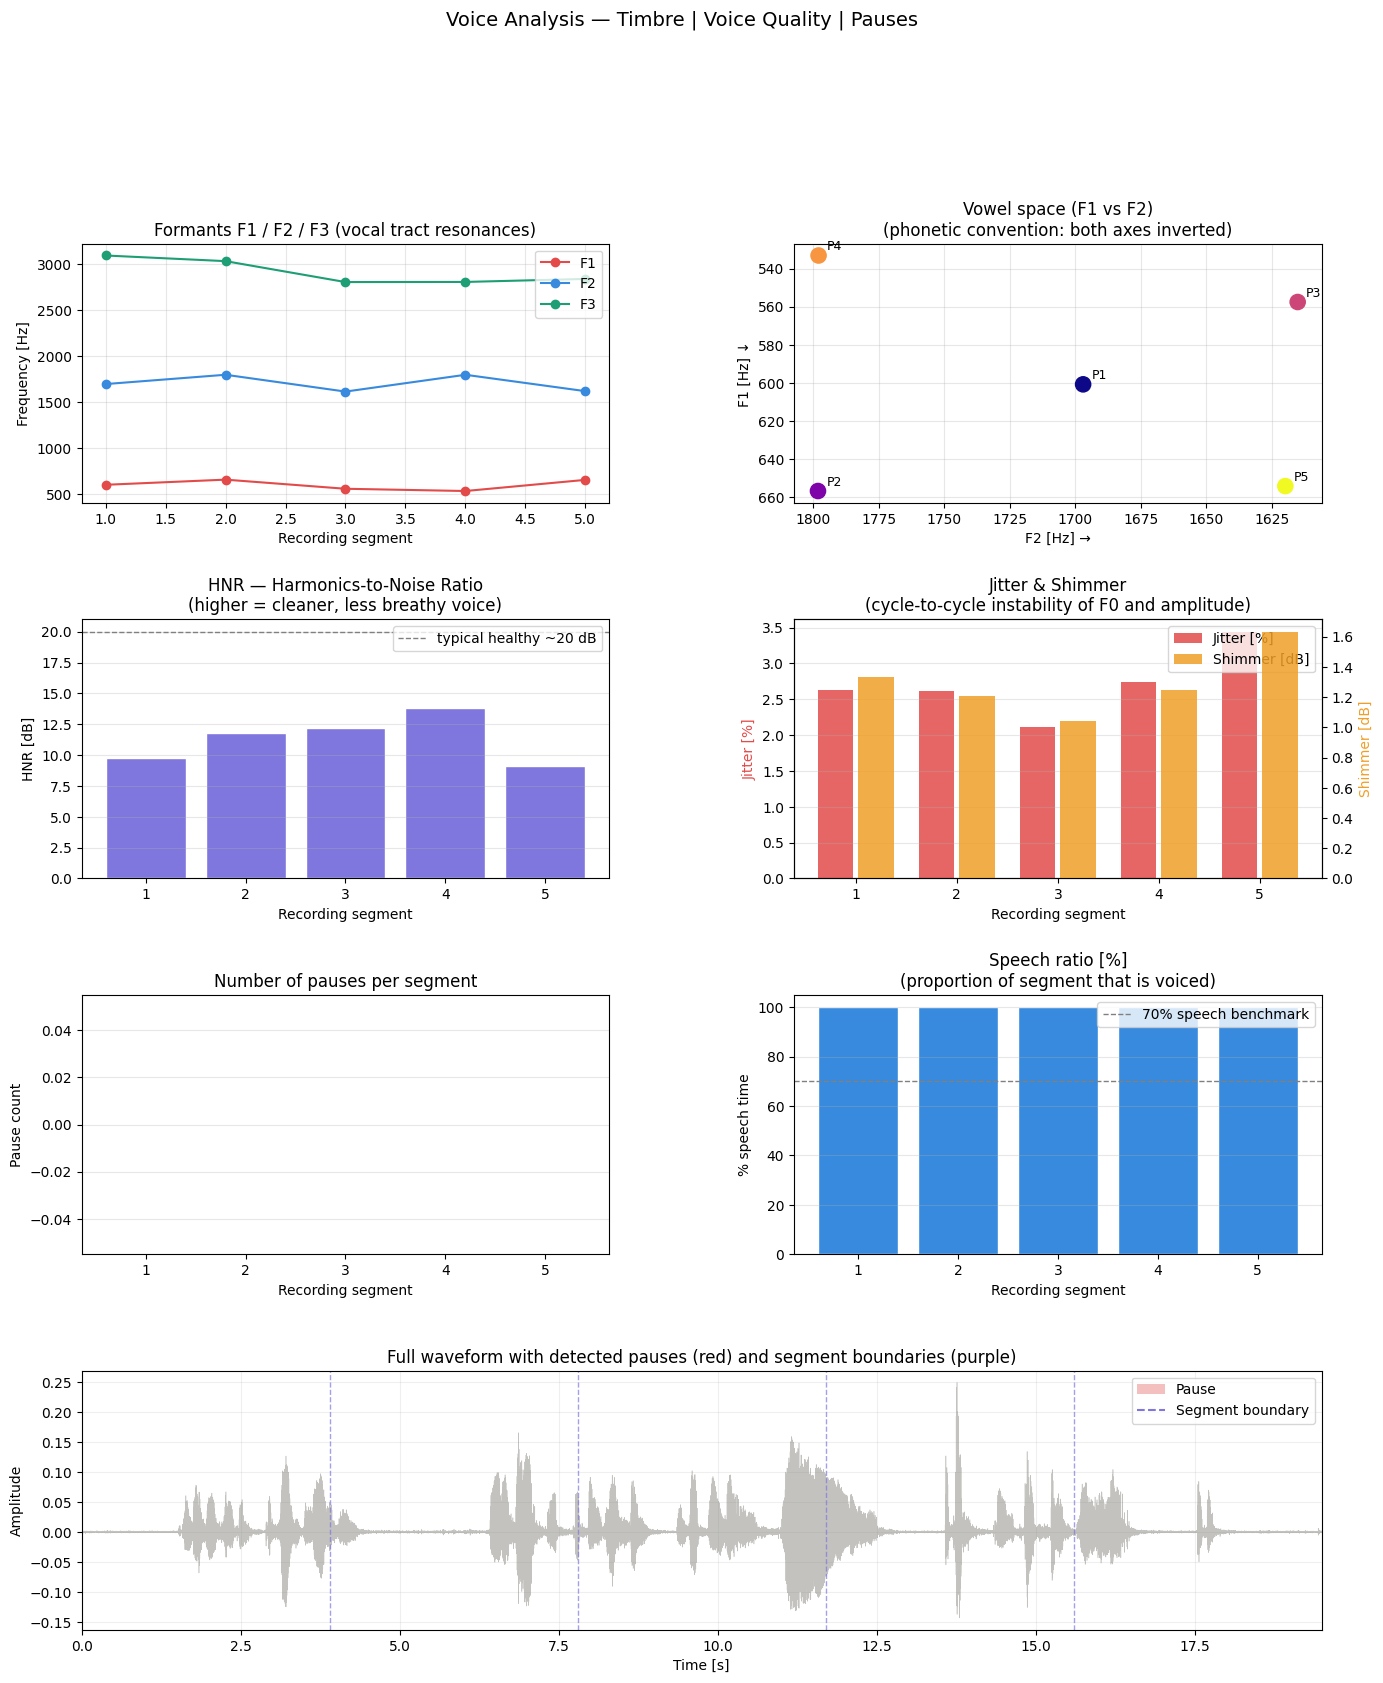

Saved: voice_analysis_extended.png


In [25]:
parts = results_df["part"]
fig = plt.figure(figsize=(16, 18))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- 7A. Formants F1 / F2 / F3 over segments ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(parts, results_df["F1_mean_hz"], "o-", label="F1", color="#E24B4A")
ax1.plot(parts, results_df["F2_mean_hz"], "o-", label="F2", color="#378ADD")
ax1.plot(parts, results_df["F3_mean_hz"], "o-", label="F3", color="#1D9E75")
ax1.set_title("Formants F1 / F2 / F3 (vocal tract resonances)")
ax1.set_xlabel("Recording segment")
ax1.set_ylabel("Frequency [Hz]")
ax1.legend()
ax1.grid(alpha=0.3)

# --- 7B. Vowel space: F1 vs F2 ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(results_df["F2_mean_hz"], results_df["F1_mean_hz"],
            c=parts, cmap="plasma", s=120, zorder=3)
for _, row in results_df.iterrows():
    ax2.annotate(f"P{int(row['part'])}", (row["F2_mean_hz"], row["F1_mean_hz"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=9)
ax2.invert_xaxis()
ax2.invert_yaxis()
ax2.set_xlabel("F2 [Hz] →")
ax2.set_ylabel("F1 [Hz] ↓")
ax2.set_title("Vowel space (F1 vs F2)\n(phonetic convention: both axes inverted)")
ax2.grid(alpha=0.3)

# --- 7C. HNR — voice clarity ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(parts, results_df["HNR_dB"], color="#7F77DD", edgecolor="white")
ax3.axhline(20, color="gray", linestyle="--", linewidth=1, label="typical healthy ~20 dB")
ax3.set_title("HNR — Harmonics-to-Noise Ratio\n(higher = cleaner, less breathy voice)")
ax3.set_xlabel("Recording segment")
ax3.set_ylabel("HNR [dB]")
ax3.legend()
ax3.grid(alpha=0.3, axis="y")

# --- 7D. Jitter and Shimmer ---
ax4   = fig.add_subplot(gs[1, 1])
x     = np.array(parts)
ax4.bar(x - 0.2, results_df["jitter_local_pct"], width=0.35,
        label="Jitter [%]", color="#E24B4A", alpha=0.85)
ax4_r = ax4.twinx()
ax4_r.bar(x + 0.2, results_df["shimmer_local_dB"], width=0.35,
           label="Shimmer [dB]", color="#EF9F27", alpha=0.85)
ax4.set_title("Jitter & Shimmer\n(cycle-to-cycle instability of F0 and amplitude)")
ax4.set_xlabel("Recording segment")
ax4.set_ylabel("Jitter [%]", color="#E24B4A")
ax4_r.set_ylabel("Shimmer [dB]", color="#EF9F27")
ax4.set_xticks(x)
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_r.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
ax4.grid(alpha=0.3, axis="y")

# --- 7E. Pause count per segment ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.bar(parts, results_df["n_pauses"], color="#1D9E75", edgecolor="white")
ax5.set_title("Number of pauses per segment")
ax5.set_xlabel("Recording segment")
ax5.set_ylabel("Pause count")
ax5.grid(alpha=0.3, axis="y")

# --- 7F. Speech ratio ---
ax6 = fig.add_subplot(gs[2, 1])
ax6.bar(parts, results_df["speech_ratio"] * 100, color="#378ADD", edgecolor="white")
ax6.axhline(70, color="gray", linestyle="--", linewidth=1, label="70% speech benchmark")
ax6.set_ylim(0, 105)
ax6.set_title("Speech ratio [%]\n(proportion of segment that is voiced)")
ax6.set_xlabel("Recording segment")
ax6.set_ylabel("% speech time")
ax6.legend()
ax6.grid(alpha=0.3, axis="y")

# --- 7G. Full waveform timeline with pauses highlighted ---
ax7 = fig.add_subplot(gs[3, :])
times = np.linspace(0, duration_sec, len(y))
ax7.plot(times, y, color="#888780", alpha=0.5, linewidth=0.4)

for _, p in pauses_df.iterrows():
    ax7.axvspan(p["abs_start"], p["abs_start"] + p["duration_sec"],
                alpha=0.35, color="#E24B4A", label="_nolegend_")

for s in segments[1:]:
    ax7.axvline(s["start_time"], color="#7F77DD", linestyle="--", linewidth=1, alpha=0.7)

ax7.set_title("Full waveform with detected pauses (red) and segment boundaries (purple)")
ax7.set_xlabel("Time [s]")
ax7.set_ylabel("Amplitude")
ax7.set_xlim(0, duration_sec)
legend_elements = [
    Patch(facecolor="#E24B4A", alpha=0.35, label="Pause"),
    plt.Line2D([0], [0], color="#7F77DD", linestyle="--", label="Segment boundary")
]
ax7.legend(handles=legend_elements, loc="upper right")
ax7.grid(alpha=0.2)

plt.suptitle("Voice Analysis — Timbre | Voice Quality | Pauses", fontsize=14, y=1.01)
plt.savefig("voice_analysis_extended.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: voice_analysis_extended.png")


### PART 8. TIMBRE DETAIL — spectral contrast + delta-MFCC

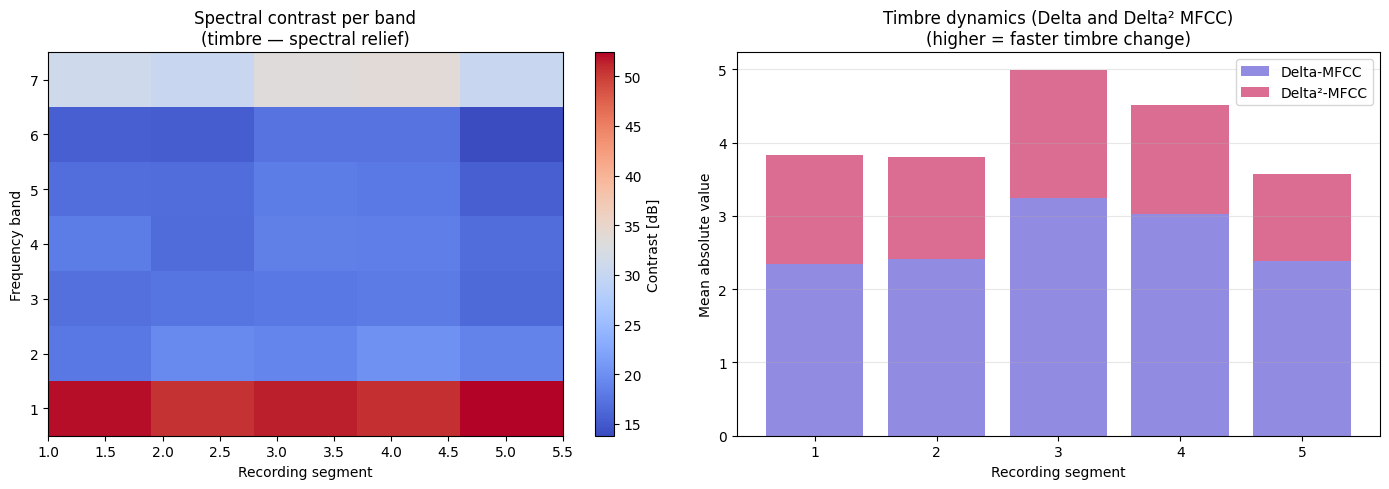

Saved: voice_timbre_detail.png
Temporary WAV removed: /var/folders/1k/vrdhlm2d26jdy9x305v501zw0000gn/T/tmp4ct3uzqq.wav


In [26]:
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spectral contrast heatmap (frequency bands × segments)
contrast_cols = [c for c in results_df.columns if c.startswith("spec_contrast_band")]
contrast_data = results_df[contrast_cols].values.T
im = axes[0].imshow(contrast_data, aspect="auto", cmap="coolwarm",
                     extent=[1, N_PARTS + 0.5, 0.5, len(contrast_cols) + 0.5])
axes[0].set_xlabel("Recording segment")
axes[0].set_ylabel("Frequency band")
axes[0].set_title("Spectral contrast per band\n(timbre — spectral relief)")
plt.colorbar(im, ax=axes[0], label="Contrast [dB]")

# Delta and Delta² MFCC — timbre dynamics
axes[1].bar(parts, results_df["delta_mfcc_mean_abs"],
            label="Delta-MFCC", color="#7F77DD", alpha=0.85)
axes[1].bar(parts, results_df["delta2_mfcc_mean_abs"],
            bottom=results_df["delta_mfcc_mean_abs"],
            label="Delta²-MFCC", color="#D4537E", alpha=0.85)
axes[1].set_title("Timbre dynamics (Delta and Delta² MFCC)\n(higher = faster timbre change)")
axes[1].set_xlabel("Recording segment")
axes[1].set_ylabel("Mean absolute value")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("voice_timbre_detail.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: voice_timbre_detail.png")

# ============================================
# PART 9. CLEANUP TEMPORARY WAV
# ============================================
os.remove(WAV_FILE)
print(f"Temporary WAV removed: {WAV_FILE}")


# COMPARING TWO PEOPLE

In [27]:
import os
import tempfile
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import soundfile as sf
import parselmouth
from parselmouth.praat import call
from matplotlib.patches import Patch
 
# --- File paths ---
FILE_KAMIL  = "Ch_Kamil.m4a"   # full recording, used from the beginning
FILE_MONIKA = "Ch_Monika.m4a"  # Monika starts speaking at second 4 — trimmed below
 
MONIKA_OFFSET_SEC = 4.0        # seconds to skip at the start of Monika's file
 
# --- DSP settings ---
TARGET_SR    = 16000
FRAME_LENGTH = 2048
HOP_LENGTH   = 512
FMIN         = 50
FMAX         = 400
 
# Silence threshold for pause detection
SILENCE_THRESHOLD_DB = -40   # dB; adjust if noisy recording
 
# Number of equal segments to split each recording into
N_PARTS = 5
 
# Speaker labels and plot colours
SPEAKERS = {
    "Kamil":  {"file": FILE_KAMIL,  "color": "#378ADD", "offset": 0.0},
    "Monika": {"file": FILE_MONIKA, "color": "#E24B4A", "offset": MONIKA_OFFSET_SEC},
}

### Loading the audio

In [28]:
def load_speaker(file_path, offset_sec, sr=TARGET_SR):
    """
    Load an audio file with librosa, trim the first `offset_sec` seconds,
    write a temporary WAV for Praat, and return (audio_array, sample_rate,
    duration_sec, parselmouth.Sound, wav_path).
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Audio file not found: {file_path}")
 
    y_full, sr_out = librosa.load(file_path, sr=sr, mono=True)
 
    # Trim leading silence / unused seconds
    offset_samples = int(offset_sec * sr_out)
    y = y_full[offset_samples:]
 
    duration = librosa.get_duration(y=y, sr=sr_out)
    print(f"  Loaded '{file_path}' | offset={offset_sec}s | "
          f"duration after trim={duration:.2f}s")
 
    # Write temporary WAV so Praat can read it
    tmp = tempfile.NamedTemporaryFile(suffix=".wav", delete=False)
    wav_path = tmp.name
    tmp.close()
    sf.write(wav_path, y, sr_out, subtype="PCM_16")
 
    snd = parselmouth.Sound(wav_path)
    return y, sr_out, duration, snd, wav_path
 
 
print("Loading audio files...")
audio_data = {}
for name, cfg in SPEAKERS.items():
    print(f"\n[{name}]")
    y, sr, dur, snd, wav = load_speaker(cfg["file"], cfg["offset"])
    audio_data[name] = {"y": y, "sr": sr, "duration": dur, "snd": snd, "wav": wav}

Loading audio files...

[Kamil]
  Loaded 'Ch_Kamil.m4a' | offset=0.0s | duration after trim=14.21s

[Monika]
  Loaded 'Ch_Monika.m4a' | offset=4.0s | duration after trim=14.92s


/var/folders/1k/vrdhlm2d26jdy9x305v501zw0000gn/T/ipykernel_11010/3893006013.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  y_full, sr_out = librosa.load(file_path, sr=sr, mono=True)
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


### Segmenting recordings

In [29]:
def make_segments(y, sr, n_parts=N_PARTS):
    samples_per_part = len(y) // n_parts
    segs = []
    for i in range(n_parts):
        start = i * samples_per_part
        end   = (i + 1) * samples_per_part if i < n_parts - 1 else len(y)
        segs.append({
            "part":       i + 1,
            "start_time": start / sr,
            "end_time":   end / sr,
            "audio":      y[start:end],
        })
    return segs
 
for name in SPEAKERS:
    audio_data[name]["segments"] = make_segments(
        audio_data[name]["y"], audio_data[name]["sr"]
    )
 

### Analysis functions

In [30]:
def analyze_timbre(audio, sr, hop_length=HOP_LENGTH):
    mfcc        = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13, hop_length=hop_length)
    delta_mfcc  = librosa.feature.delta(mfcc)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)
    contrast    = librosa.feature.spectral_contrast(y=audio, sr=sr, hop_length=hop_length)
    chroma      = librosa.feature.chroma_stft(y=audio, sr=sr, hop_length=hop_length)
 
    result = {}
    for i in range(mfcc.shape[0]):
        result[f"mfcc_{i+1}_mean"] = float(np.mean(mfcc[i]))
        result[f"mfcc_{i+1}_std"]  = float(np.std(mfcc[i]))
 
    result["delta_mfcc_mean_abs"]  = float(np.mean(np.abs(delta_mfcc)))
    result["delta2_mfcc_mean_abs"] = float(np.mean(np.abs(delta2_mfcc)))
 
    for b in range(contrast.shape[0]):
        result[f"spec_contrast_band{b+1}"] = float(np.mean(contrast[b]))
 
    result["chroma_variance"] = float(np.var(np.mean(chroma, axis=1)))
    return result
 
 
def analyze_voice_quality(snd_full, start_time, end_time):
    part_snd = snd_full.extract_part(
        from_time=start_time, to_time=end_time, preserve_times=False
    )
    result = {}
 
    # Formants
    try:
        formant  = call(part_snd, "To Formant (burg)", 0, 5, 5500, 0.025, 50)
        n_points = max(1, int((end_time - start_time) / 0.01))
        f1_vals, f2_vals, f3_vals = [], [], []
        for t_idx in range(n_points):
            t  = t_idx * 0.01
            f1 = call(formant, "Get value at time", 1, t, "Hertz", "Linear")
            f2 = call(formant, "Get value at time", 2, t, "Hertz", "Linear")
            f3 = call(formant, "Get value at time", 3, t, "Hertz", "Linear")
            if not np.isnan(f1): f1_vals.append(f1)
            if not np.isnan(f2): f2_vals.append(f2)
            if not np.isnan(f3): f3_vals.append(f3)
        result["F1_mean_hz"] = float(np.mean(f1_vals)) if f1_vals else np.nan
        result["F2_mean_hz"] = float(np.mean(f2_vals)) if f2_vals else np.nan
        result["F3_mean_hz"] = float(np.mean(f3_vals)) if f3_vals else np.nan
        result["F1_std_hz"]  = float(np.std(f1_vals))  if f1_vals else np.nan
        result["F2_std_hz"]  = float(np.std(f2_vals))  if f2_vals else np.nan
    except Exception as e:
        print(f"  [Formant error] {e}")
        result.update({k: np.nan for k in
                        ["F1_mean_hz","F2_mean_hz","F3_mean_hz","F1_std_hz","F2_std_hz"]})
 
    # HNR
    try:
        harmonicity  = call(part_snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr          = call(harmonicity, "Get mean", 0, 0)
        result["HNR_dB"] = float(hnr) if not np.isnan(hnr) else np.nan
    except Exception as e:
        print(f"  [HNR error] {e}")
        result["HNR_dB"] = np.nan
 
    # Jitter and Shimmer
    try:
        pitch         = call(part_snd, "To Pitch", 0, FMIN, FMAX)
        point_process = call([part_snd, pitch], "To PointProcess (cc)")
        jitter_local  = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        shimmer_dB    = call([part_snd, point_process],
                             "Get shimmer (local_dB)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        result["jitter_local_pct"]  = float(jitter_local * 100) if jitter_local else np.nan
        result["shimmer_local_dB"]  = float(shimmer_dB)         if shimmer_dB   else np.nan
    except Exception as e:
        print(f"  [Jitter/Shimmer error] {e}")
        result["jitter_local_pct"] = np.nan
        result["shimmer_local_dB"] = np.nan
 
    return result
 
 
def analyze_pauses(audio, sr, threshold_db=SILENCE_THRESHOLD_DB,
                   hop_length=HOP_LENGTH, min_pause_frames=3):
    rms            = librosa.feature.rms(y=audio, hop_length=hop_length)[0]
    rms_db         = librosa.amplitude_to_db(rms, ref=np.max)
    is_silent      = rms_db < threshold_db
    frame_duration = hop_length / sr
 
    pauses, in_pause, pause_start = [], False, 0
    for i, silent in enumerate(is_silent):
        if silent and not in_pause:
            in_pause, pause_start = True, i
        elif not silent and in_pause:
            pl = i - pause_start
            if pl >= min_pause_frames:
                pauses.append({"start_sec": pause_start * frame_duration,
                                "end_sec":   i * frame_duration,
                                "duration_sec": pl * frame_duration})
            in_pause = False
    if in_pause:
        pl = len(is_silent) - pause_start
        if pl >= min_pause_frames:
            pauses.append({"start_sec": pause_start * frame_duration,
                            "end_sec":   len(is_silent) * frame_duration,
                            "duration_sec": pl * frame_duration})
 
    total_dur   = len(audio) / sr
    total_pause = sum(p["duration_sec"] for p in pauses)
    speech_dur  = total_dur - total_pause
    stats = {
        "n_pauses":          len(pauses),
        "total_pause_sec":   float(total_pause),
        "speech_ratio":      float(speech_dur / total_dur) if total_dur > 0 else np.nan,
        "mean_pause_sec":    float(np.mean([p["duration_sec"] for p in pauses])) if pauses else 0.0,
        "max_pause_sec":     float(max([p["duration_sec"] for p in pauses]))      if pauses else 0.0,
        "pauses_per_second": float(len(pauses) / speech_dur) if speech_dur > 0 else np.nan,
    }
    return stats, pauses

### Running analysis for both files

In [31]:
all_dfs        = {}   # segment-level DataFrames per speaker
all_pauses_dfs = {}   # pause-detail DataFrames per speaker
 
for name in SPEAKERS:
    print(f"\n=== Analysing {name} ===")
    d        = audio_data[name]
    rows     = []
    p_detail = []
 
    for s in d["segments"]:
        print(f"  Part {s['part']} ({s['start_time']:.2f}s – {s['end_time']:.2f}s)")
        timbre      = analyze_timbre(s["audio"], d["sr"])
        quality     = analyze_voice_quality(d["snd"], s["start_time"], s["end_time"])
        p_stats, pl = analyze_pauses(s["audio"], d["sr"])
 
        rows.append({
            "speaker": name, "part": s["part"],
            "start_time_sec": s["start_time"], "end_time_sec": s["end_time"],
            **timbre, **quality, **p_stats
        })
        for p in pl:
            p_detail.append({"speaker": name, "part": s["part"],
                              "abs_start": s["start_time"] + p["start_sec"], **p})
 
    all_dfs[name]        = pd.DataFrame(rows)
    all_pauses_dfs[name] = pd.DataFrame(p_detail)
 
# Combined DataFrames
combined_df = pd.concat(all_dfs.values(), ignore_index=True)
combined_pauses_df = pd.concat(
    [df for df in all_pauses_dfs.values() if len(df) > 0], ignore_index=True
) if any(len(df) > 0 for df in all_pauses_dfs.values()) else pd.DataFrame()


=== Analysing Kamil ===
  Part 1 (0.00s – 2.84s)
  Part 2 (2.84s – 5.68s)
  Part 3 (5.68s – 8.52s)
  Part 4 (8.52s – 11.37s)
  Part 5 (11.37s – 14.21s)

=== Analysing Monika ===
  Part 1 (0.00s – 2.98s)
  Part 2 (2.98s – 5.97s)
  Part 3 (5.97s – 8.95s)
  Part 4 (8.95s – 11.94s)
  Part 5 (11.94s – 14.92s)


### Summary table + delta

In [32]:
key_metrics = ["F1_mean_hz", "F2_mean_hz", "F3_mean_hz", "HNR_dB",
               "jitter_local_pct", "shimmer_local_dB",
               "n_pauses", "speech_ratio", "mean_pause_sec",
               "delta_mfcc_mean_abs", "chroma_variance"]
 
summary = {}
for name in SPEAKERS:
    summary[name] = all_dfs[name][key_metrics].mean()
 
summary_df = pd.DataFrame(summary).T
summary_df["delta (Kamil − Monika)"] = (
    summary_df.loc["Kamil"] - summary_df.loc["Monika"]
)
 
print("\n\n=== OVERALL COMPARISON SUMMARY ===")
print(summary_df[key_metrics].to_string())
print("\n=== DELTA (Kamil − Monika) ===")
print(summary_df[["delta (Kamil − Monika)"]].to_string())



=== OVERALL COMPARISON SUMMARY ===
        F1_mean_hz   F2_mean_hz   F3_mean_hz    HNR_dB  jitter_local_pct  shimmer_local_dB  n_pauses  speech_ratio  mean_pause_sec  delta_mfcc_mean_abs  chroma_variance
Kamil   616.080926  1598.815717  2868.165699  8.862240          3.422448          1.384314       0.0           1.0             0.0             2.740366         0.007813
Monika  668.622470  1725.838936  2894.293788  9.223544          3.188706          1.461565       0.0           1.0             0.0             2.766585         0.008868

=== DELTA (Kamil − Monika) ===
        delta (Kamil − Monika)
Kamil                      NaN
Monika                     NaN


### Saving results

In [33]:
combined_df.to_csv("voice_comparison_segments.csv", index=False)
summary_df.to_csv("voice_comparison_summary.csv")
if not combined_pauses_df.empty:
    combined_pauses_df.to_csv("voice_comparison_pauses.csv", index=False)
print("\nSaved: voice_comparison_segments.csv, voice_comparison_summary.csv")


Saved: voice_comparison_segments.csv, voice_comparison_summary.csv


### Visualizations

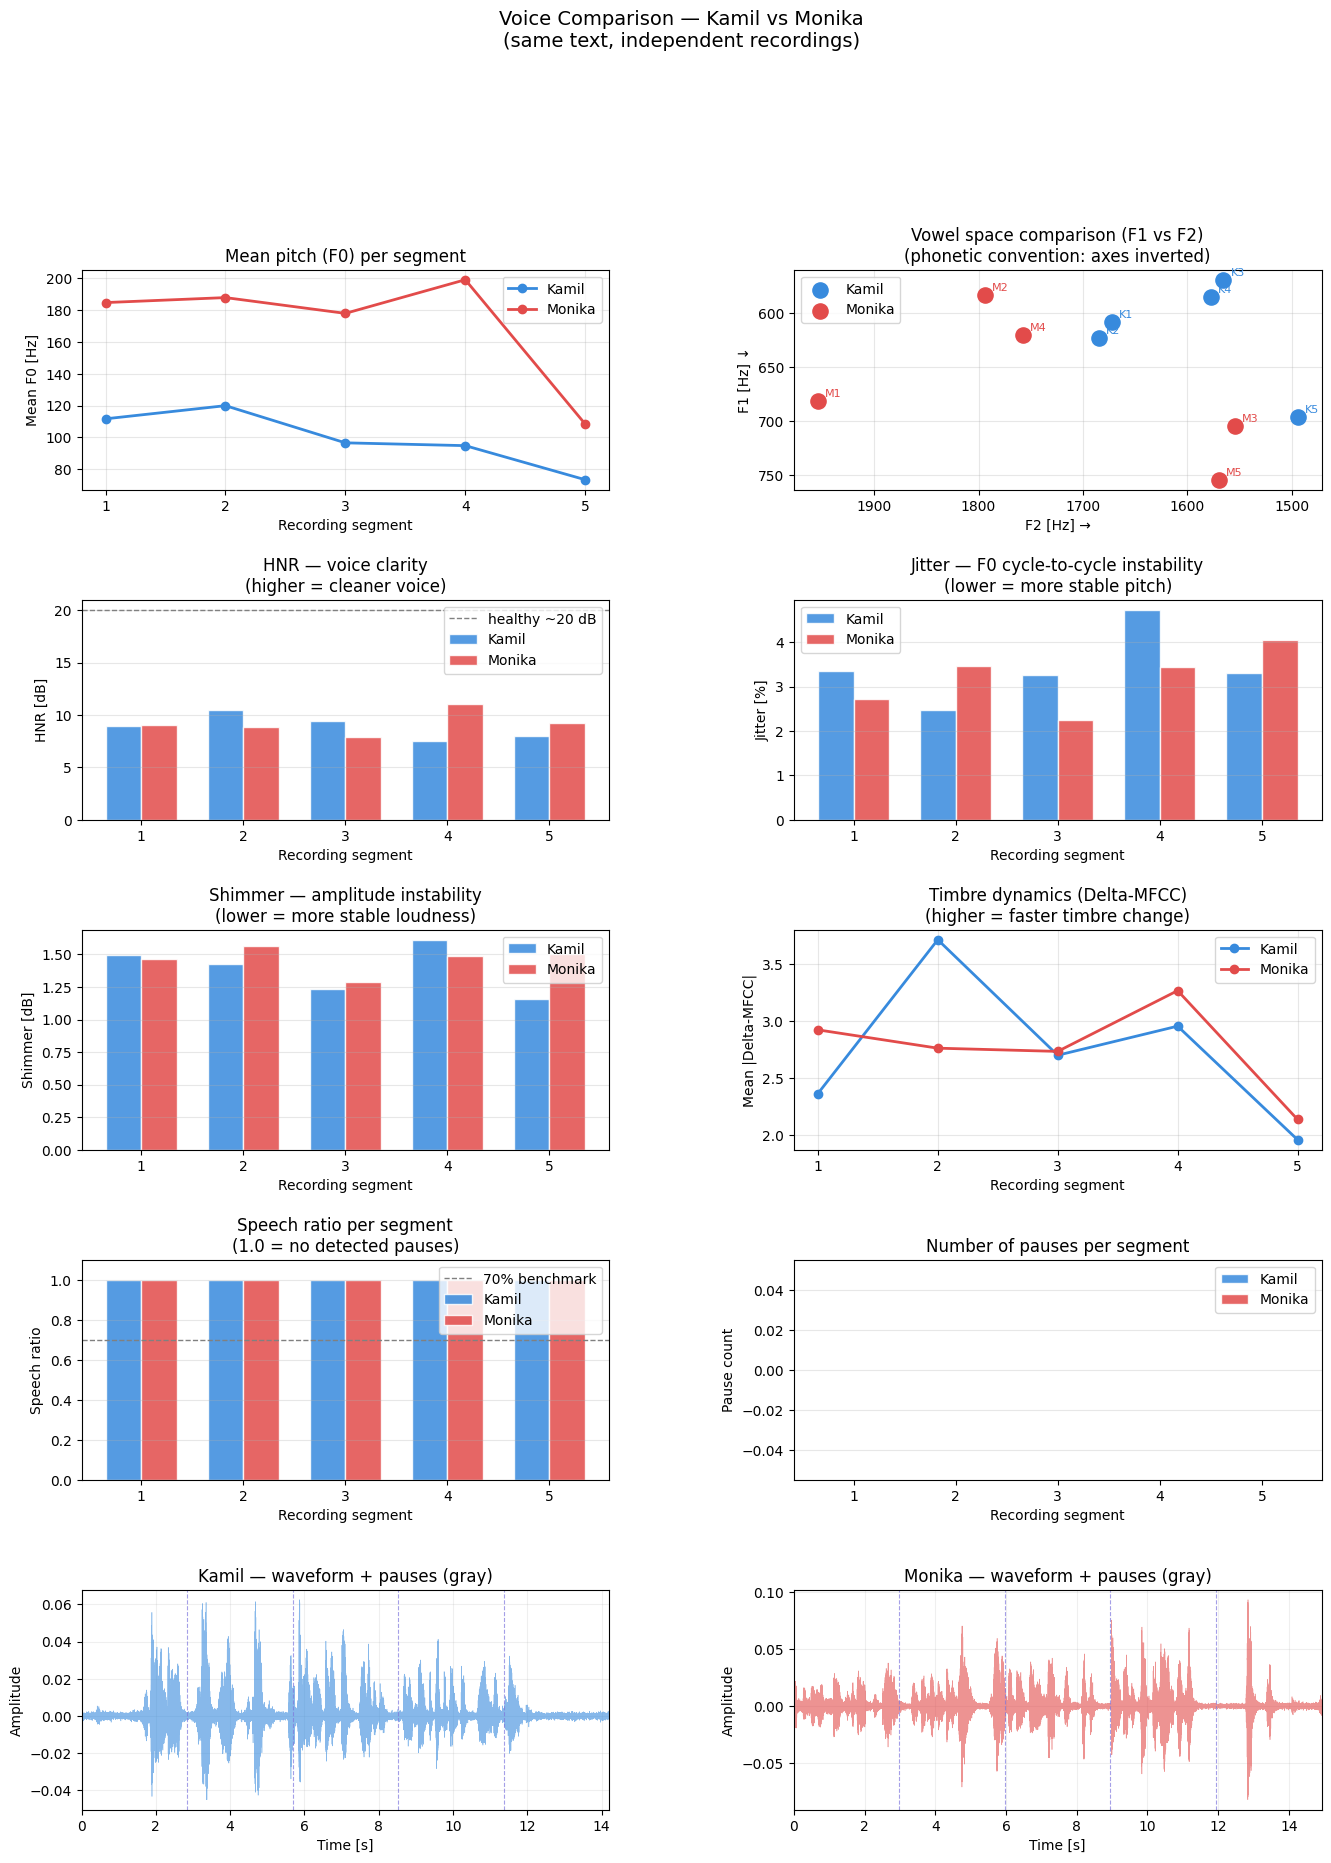

Saved: voice_comparison.png


In [34]:
colors = {name: cfg["color"] for name, cfg in SPEAKERS.items()}
parts  = np.arange(1, N_PARTS + 1)
 
fig = plt.figure(figsize=(16, 20))
gs  = gridspec.GridSpec(5, 2, figure=fig, hspace=0.5, wspace=0.35)
 
# Helper: overlay line plot for one metric
def overlay_lines(ax, metric, ylabel, title):
    for name in SPEAKERS:
        df = all_dfs[name]
        ax.plot(df["part"], df[metric], "o-",
                label=name, color=colors[name], linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Recording segment")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.set_xticks(parts)
    ax.grid(alpha=0.3)
 
# Helper: grouped bar chart for one metric
def grouped_bars(ax, metric, ylabel, title, reference_line=None, ref_label=""):
    width = 0.35
    x = np.array(parts)
    for i, name in enumerate(SPEAKERS):
        df     = all_dfs[name]
        offset = (i - 0.5) * width
        ax.bar(x + offset, df[metric], width=width,
               label=name, color=colors[name], alpha=0.85, edgecolor="white")
    if reference_line is not None:
        ax.axhline(reference_line, color="gray", linestyle="--",
                   linewidth=1, label=ref_label)
    ax.set_title(title)
    ax.set_xlabel("Recording segment")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
 
# --- 8A. Pitch (F0) — from original single-speaker analysis ---
#   Re-compute mean F0 per segment for both speakers
for name in SPEAKERS:
    d    = audio_data[name]
    f0s  = []
    for s in d["segments"]:
        f0 = librosa.yin(s["audio"], fmin=FMIN, fmax=FMAX, sr=d["sr"],
                         frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)
        f0_clean = np.where((f0 >= FMIN) & (f0 <= FMAX), f0, np.nan)
        f0s.append(float(np.nanmean(f0_clean)) if np.any(~np.isnan(f0_clean)) else np.nan)
    all_dfs[name]["f0_mean_hz"] = f0s
 
ax1 = fig.add_subplot(gs[0, 0])
overlay_lines(ax1, "f0_mean_hz", "Mean F0 [Hz]",
              "Mean pitch (F0) per segment")
 
# --- 8B. Vowel space: F1 vs F2 (both speakers overlaid) ---
ax2 = fig.add_subplot(gs[0, 1])
for name in SPEAKERS:
    df = all_dfs[name]
    ax2.scatter(df["F2_mean_hz"], df["F1_mean_hz"],
                color=colors[name], s=120, zorder=3, label=name)
    for _, row in df.iterrows():
        ax2.annotate(f"{name[0]}{int(row['part'])}",
                     (row["F2_mean_hz"], row["F1_mean_hz"]),
                     textcoords="offset points", xytext=(5, 3), fontsize=8,
                     color=colors[name])
ax2.invert_xaxis()
ax2.invert_yaxis()
ax2.set_xlabel("F2 [Hz] →")
ax2.set_ylabel("F1 [Hz] ↓")
ax2.set_title("Vowel space comparison (F1 vs F2)\n(phonetic convention: axes inverted)")
ax2.legend()
ax2.grid(alpha=0.3)
 
# --- 8C. HNR ---
ax3 = fig.add_subplot(gs[1, 0])
grouped_bars(ax3, "HNR_dB", "HNR [dB]",
             "HNR — voice clarity\n(higher = cleaner voice)",
             reference_line=20, ref_label="healthy ~20 dB")
 
# --- 8D. Jitter ---
ax4 = fig.add_subplot(gs[1, 1])
grouped_bars(ax4, "jitter_local_pct", "Jitter [%]",
             "Jitter — F0 cycle-to-cycle instability\n(lower = more stable pitch)")
 
# --- 8E. Shimmer ---
ax5 = fig.add_subplot(gs[2, 0])
grouped_bars(ax5, "shimmer_local_dB", "Shimmer [dB]",
             "Shimmer — amplitude instability\n(lower = more stable loudness)")
 
# --- 8F. Timbre dynamics (Delta-MFCC) ---
ax6 = fig.add_subplot(gs[2, 1])
overlay_lines(ax6, "delta_mfcc_mean_abs", "Mean |Delta-MFCC|",
              "Timbre dynamics (Delta-MFCC)\n(higher = faster timbre change)")
 
# --- 8G. Speech ratio ---
ax7 = fig.add_subplot(gs[3, 0])
grouped_bars(ax7, "speech_ratio", "Speech ratio",
             "Speech ratio per segment\n(1.0 = no detected pauses)",
             reference_line=0.70, ref_label="70% benchmark")
ax7.set_ylim(0, 1.1)
 
# --- 8H. Pause count ---
ax8 = fig.add_subplot(gs[3, 1])
grouped_bars(ax8, "n_pauses", "Pause count",
             "Number of pauses per segment")
 
# --- 8I. Full waveform comparison (stacked) ---
ax9  = fig.add_subplot(gs[4, 0])
ax10 = fig.add_subplot(gs[4, 1])
 
for ax, name in zip([ax9, ax10], SPEAKERS):
    d     = audio_data[name]
    times = np.linspace(0, d["duration"], len(d["y"]))
    ax.plot(times, d["y"], color=colors[name], alpha=0.6, linewidth=0.4)
 
    # Shade detected pauses
    if not all_pauses_dfs[name].empty:
        for _, p in all_pauses_dfs[name].iterrows():
            ax.axvspan(p["abs_start"], p["abs_start"] + p["duration_sec"],
                       alpha=0.3, color="#888780")
 
    # Segment boundary lines
    for s in audio_data[name]["segments"][1:]:
        ax.axvline(s["start_time"], color="#7F77DD",
                   linestyle="--", linewidth=0.8, alpha=0.7)
 
    ax.set_title(f"{name} — waveform + pauses (gray)")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(0, d["duration"])
    ax.grid(alpha=0.2)
 
plt.suptitle("Voice Comparison — Kamil vs Monika\n(same text, independent recordings)",
             fontsize=14, y=1.01)
plt.savefig("voice_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: voice_comparison.png")

- **F0 (pitch)** — how high or low the voice sounds, like the difference between a bass and a tenor.
- **F1 / F2 (formants)** — the resonance frequencies shaped by tongue and jaw position that determine which vowel you hear (e.g. "ee" vs "ah").
- **HNR (harmonics-to-noise ratio)** — how much clean tone vs breathy noise is in the voice, essentially how "clear" you sound.
- **Jitter** — how much the pitch wobbles from one vocal-fold cycle to the next, so higher jitter means a rougher, less controlled voice.
- **Shimmer** — the same wobble idea but for loudness instead of pitch, where higher values mean the volume flickers unevenly.
- **Delta-MFCC (timbre dynamics)** — how fast the vocal colour changes over time, capturing whether someone speaks expressively or monotonously.
- **Chroma variance** — how much the distribution of musical pitch classes varies, reflecting tonal richness and melodic variety in speech.
- **Speech ratio** — the fraction of time actually spent talking vs pausing, where 1.0 means nonstop speech with no detected silence.

### Spider chart


=== RADAR RAW VALUES (mean per speaker) ===

  Kamil:
    F1_mean_hz                     = 616.0809
    F2_mean_hz                     = 1598.8157
    HNR_dB                         = 8.8622
    jitter_local_pct               = 3.4224
    shimmer_local_dB               = 1.3843
    delta_mfcc_mean_abs            = 2.7404
    chroma_variance                = 0.0078

  Monika:
    F1_mean_hz                     = 668.6225
    F2_mean_hz                     = 1725.8389
    HNR_dB                         = 9.2235
    jitter_local_pct               = 3.1887
    shimmer_local_dB               = 1.4616
    delta_mfcc_mean_abs            = 2.7666
    chroma_variance                = 0.0089

=== RADAR NORMALISED VALUES ===
  Kamil: [0.959, 0.962, 0.98, 1.035, 0.973, 0.995, 0.937]
  Monika: [1.041, 1.038, 1.02, 0.965, 1.027, 1.005, 1.063]


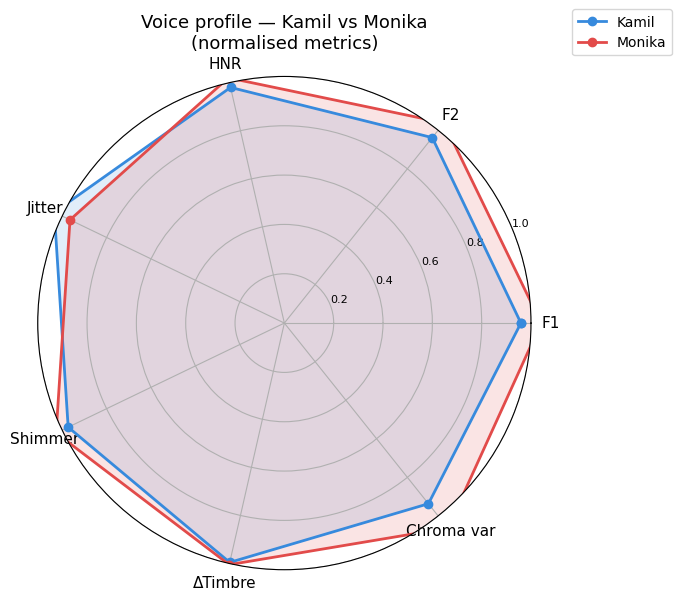

Saved: voice_radar.png


In [37]:
radar_metrics = ["F1_mean_hz", "F2_mean_hz", "HNR_dB",
                 "jitter_local_pct", "shimmer_local_dB",
                 "delta_mfcc_mean_abs", "chroma_variance"]
radar_labels  = ["F1", "F2", "HNR", "Jitter", "Shimmer", "ΔTimbre", "Chroma var"]
 
# --- Diagnostic: print raw values before normalisation ---
print("\n=== RADAR RAW VALUES (mean per speaker) ===")
for name in SPEAKERS:
    row = summary_df.loc[name, radar_metrics]
    print(f"\n  {name}:")
    for m, v in row.items():
        flag = "  ← NaN!" if pd.isna(v) else ""
        print(f"    {m:30s} = {v:.4f}{flag}" if not pd.isna(v) else f"    {m:30s} = NaN{flag}")
 
# --- Pull values; keep only SPEAKERS rows (exclude the delta row) ---
vals = {}
for name in SPEAKERS:
    v = summary_df.loc[name, radar_metrics].values.astype(float)
    vals[name] = v
 
# --- Impute NaN with the cross-speaker column mean so no axis collapses ---
# (A speaker with a failed Praat call gets the average of the other speaker
#  for that axis, which is neutral rather than misleading.)
all_vals = np.vstack(list(vals.values()))          # shape: (n_speakers, n_metrics)
col_means = np.nanmean(all_vals, axis=0)           # fallback value per metric
 
for name in SPEAKERS:
    nan_mask = np.isnan(vals[name])
    if nan_mask.any():
        print(f"\n  [Radar] Imputing {nan_mask.sum()} NaN(s) for {name} "
              f"with cross-speaker mean")
        vals[name][nan_mask] = col_means[nan_mask]
 
# --- Normalise as ratio to cross-speaker mean ---
all_vals_clean = np.vstack(list(vals.values()))
col_means = all_vals_clean.mean(axis=0)
col_means = np.where(col_means == 0, 1.0, col_means)

norm_vals = {}
for name in SPEAKERS:
    norm_vals[name] = vals[name] / col_means

# Update ylim to fit the data
max_val = max(nv.max() for nv in norm_vals.values())    
 
print("\n=== RADAR NORMALISED VALUES ===")
for name in SPEAKERS:
    print(f"  {name}: {np.round(norm_vals[name], 3).tolist()}")
 
# --- Build angles (N axes, closed polygon) ---
N      = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the loop
 
fig_r, ax_r = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
 
for name in SPEAKERS:
    v = norm_vals[name].tolist()
    v += v[:1]                           # close the polygon
    ax_r.plot(angles, v, "o-", linewidth=2, label=name, color=colors[name])
    ax_r.fill(angles, v, alpha=0.15, color=colors[name])
 
ax_r.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=11)
ax_r.set_ylim(0, 1)
ax_r.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax_r.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)
ax_r.set_title("Voice profile — Kamil vs Monika\n(normalised metrics)",
               pad=20, fontsize=13)
ax_r.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15))
plt.tight_layout()
plt.savefig("voice_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: voice_radar.png")

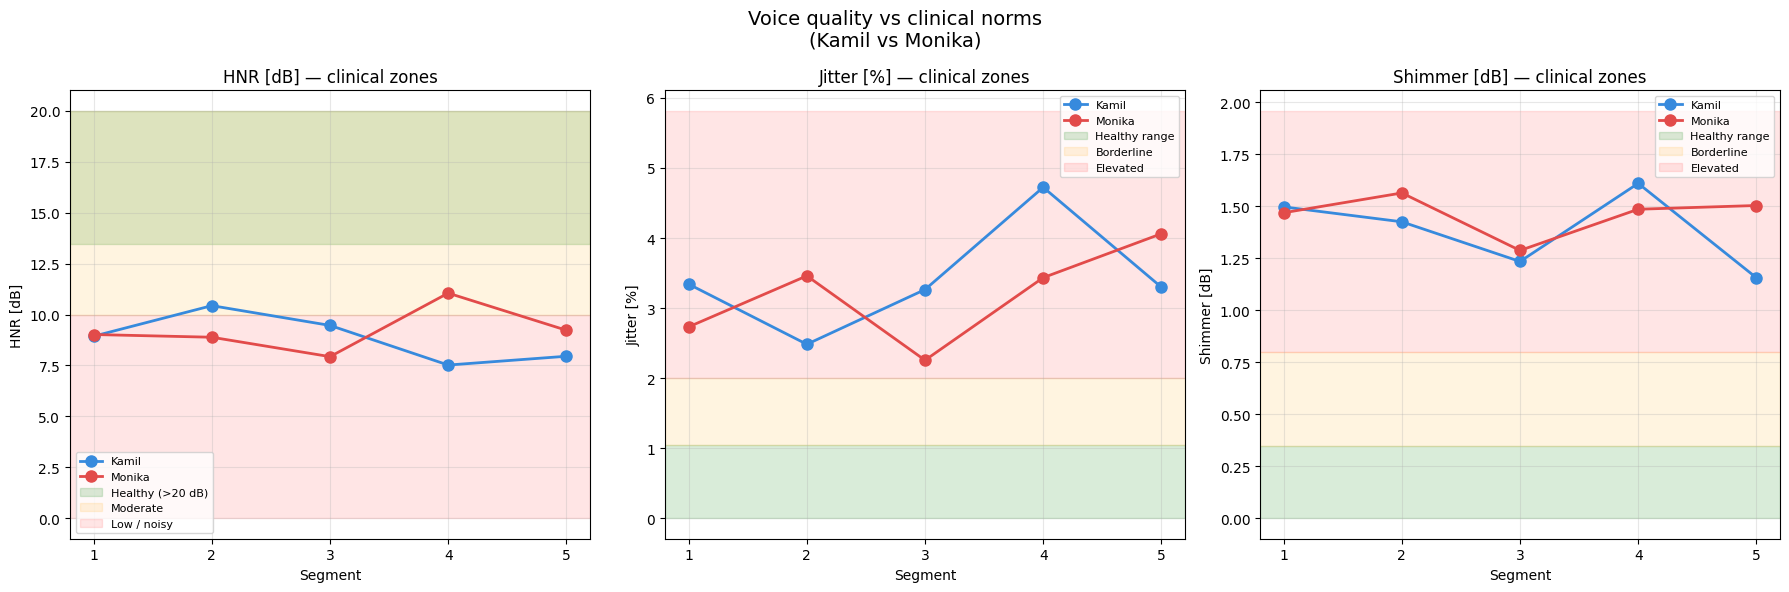

In [38]:
# === CLINICAL REFERENCE BOUNDARIES ===
# Sources: Teixeira et al. (2013), Boersma & Weenink (Praat manual),
#          Baken & Orlikoff (2000) "Clinical Measurement of Speech & Voice"

CLINICAL_NORMS = {
    "HNR_dB":           {"healthy": (20, None),  "concern": (10, 20), "label": "HNR [dB]"},
    "jitter_local_pct": {"healthy": (0, 1.04),   "concern": (1.04, 2.0), "label": "Jitter [%]"},
    "shimmer_local_dB": {"healthy": (0, 0.35),   "concern": (0.35, 0.80), "label": "Shimmer [dB]"},
}

fig_clin, axes_clin = plt.subplots(1, 3, figsize=(18, 6))

for ax, (metric, norms) in zip(axes_clin, CLINICAL_NORMS.items()):
    # Plot per-segment values for each speaker
    for name in SPEAKERS:
        df = all_dfs[name]
        ax.plot(df["part"], df[metric], "o-", label=name,
                color=colors[name], linewidth=2, markersize=8)

    # Shade clinical zones
    ymin, ymax = ax.get_ylim()
    h = norms["healthy"]
    c = norms["concern"]

    if h[1] is not None:  # bounded healthy range (jitter, shimmer)
        ax.axhspan(h[0], h[1], alpha=0.15, color="green", label="Healthy range")
        ax.axhspan(c[0], c[1], alpha=0.12, color="orange", label="Borderline")
        ax.axhspan(c[1], ymax * 1.2, alpha=0.10, color="red", label="Elevated")
    else:                 # HNR — higher is better
        ax.axhspan(h[0], ymax * 1.2, alpha=0.15, color="green", label="Healthy (>20 dB)")
        ax.axhspan(c[0], c[1], alpha=0.12, color="orange", label="Moderate")
        ax.axhspan(0, c[0], alpha=0.10, color="red", label="Low / noisy")

    ax.set_title(f"{norms['label']} — clinical zones", fontsize=12)
    ax.set_xlabel("Segment")
    ax.set_ylabel(norms["label"])
    ax.set_xticks(parts)
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=0.3)

plt.suptitle("Voice quality vs clinical norms\n(Kamil vs Monika)",
             fontsize=14)
plt.tight_layout()
plt.savefig("voice_clinical_norms.png", dpi=150, bbox_inches="tight")
plt.show()

In [40]:
# === Diagnostic summary ===
def diagnose(value, healthy_range, concern_range, higher_is_better=False):
    if higher_is_better:
        if value >= healthy_range[0]: return "Healthy"
        elif value >= concern_range[0]: return "Moderate"
        else: return "Low"
    else:
        if value <= healthy_range[1]: return "Healthy"
        elif value <= concern_range[1]: return "Borderline"
        else: return "Elevated"

diag_rows = []
for name in SPEAKERS:
    row = summary_df.loc[name]
    diag_rows.append({
        "Speaker": name,
        "HNR": f"{row['HNR_dB']:.1f} dB — {diagnose(row['HNR_dB'], (20,), (10, 20), higher_is_better=True)}",
        "Jitter": f"{row['jitter_local_pct']:.2f}% — {diagnose(row['jitter_local_pct'], (0, 1.04), (1.04, 2.0))}",
        "Shimmer": f"{row['shimmer_local_dB']:.2f} dB — {diagnose(row['shimmer_local_dB'], (0, 0.35), (0.35, 0.80))}",
    })

diag_df = pd.DataFrame(diag_rows).set_index("Speaker")
print("\n=== VOICE QUALITY DIAGNOSTIC ===")
print(diag_df.to_string())


=== VOICE QUALITY DIAGNOSTIC ===
                  HNR            Jitter             Shimmer
Speaker                                                    
Kamil    8.9 dB — Low  3.42% — Elevated  1.38 dB — Elevated
Monika   9.2 dB — Low  3.19% — Elevated  1.46 dB — Elevated
